In [1]:
# This cell is tagged for removal

import os
import pickle
from glob import glob

import numpy as np
from sklearn.metrics import r2_score

import aliases # important this goes first to configure PATH

from everest.window import Canvas, DataChannel as Channel
from everest.window.colourmaps import cmap
from everest.window import imop

from thesiscode.general import *
from analysis import analysis

## Basal heating

### Conductive solution

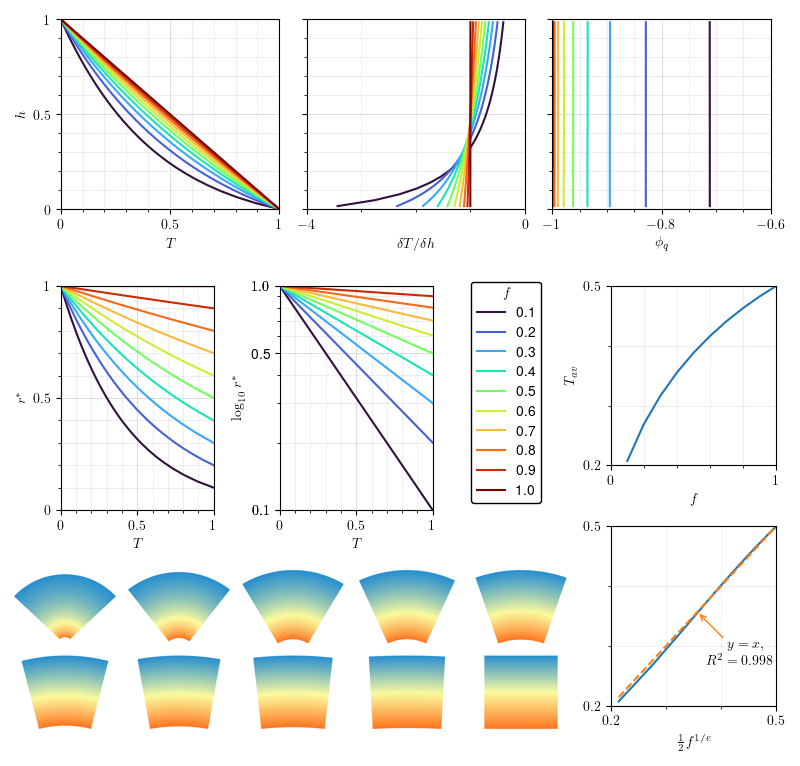

In [2]:
#| label: isocondf

impaths = sorted(os.path.relpath(path) for path in glob(os.path.join(aliases.storagedir, 'cond_f*.png')))
ims = tuple(image.fromfile(path) for path in impaths)
thumbs = imop.vstack(
    imop.hstack(*ims[:5]),
    imop.hstack(*ims[5:]),
    )

with open(os.path.join(aliases.storagedir, 'condf.pkl'), mode = 'rb') as file:
    conddata = pickle.loads(file.read())
condgeotherms, condavts, condfs = (conddata[key] for key in ('geotherms', 'avts', 'fs'))

# Canvas 0

canvas0 = Canvas(size = (8, 8/3), shape = (1, 3))
ax1 = canvas0.make_ax((0, 0))
ax2 = canvas0.make_ax((0, 1))
ax3 = canvas0.make_ax((0, 2))
for f, T in zip(condfs, condgeotherms):
    f = min(0.999, f)
    h = np.linspace(0, 1, len(T))
    dT, hdT = analysis.derivative(T, h, n = 1)
    phi = dT * s_star(hdT, f)
    ax1.line(
        Channel(T, label = '$T$'),
        Channel(h, label = '$h$', lims = (0, 1)),
        c = cmap(f, condfs, style = 'turbo'),
        )
    ax2.line(
        Channel(dT, label = r'$ \delta T / \delta h $', lims = (-4, 0), capped = (True, True)),
        Channel(hdT, label = '$h$', lims = (0, 1)),
        c = cmap(f, condfs, style = 'turbo'),
        )
    ax3.line(
        Channel(phi, label = r'$\phi_q$', lims = (-1, -0.6)),
        Channel(hdT, label = '$h$', lims = (0, 1)),
        c = cmap(f, condfs, style = 'turbo'),
        )
for ax in (ax2, ax3):
    ax.props.edges.y.ticks.major.labels = []
    ax.props.edges.y.label.visible = False

# Canvas 1

canvas1 = Canvas(shape = (1, 2), size = (5.5, 3))

ax1 = canvas1.make_ax((0, 0))
ax2 = canvas1.make_ax((0, 1))

fslopes = []

for f, T in zip(condfs, condgeotherms):

    f = min(0.999, f)

    h = np.linspace(0, 1, len(T))
    rstar = r_star(h, f)

    ax1.line(
        Tchan := Channel(T, label = '$T$'),
        Channel(rstar, label = '$r^{*}$'),
        c = cmap(f, condfs, style = 'turbo'),
        )

    ax2.line(
        Tchan,
        Channel(rstar, label = r"$r^{*}$", capped = (True, True), log = True),
        c = cmap(f, condfs, style = 'turbo'),
        )

    fslopes.append(np.mean(np.gradient(T, np.log(rstar), edge_order = 2)))

fslopes = np.array(fslopes)

# ax2.props.edges.y.swap()

ax2.props.legend.set_handles_labels(
    (row[0] for row in ax1.collections),
    (str(f) for f in condfs),
    )
ax2.props.legend.title.text = '$f$'
ax2.props.legend.title.visible = True
ax2.props.legend.mplprops['bbox_to_anchor'] = (1.75, 1.05)
# ax1.props.legend.mplprops['ncol'] = 2
ax2.props.legend.frame.colour = 'black'
ax2.props.legend.frame.visible = True

# Canvas 2

canvas2 = Canvas(size = (2.5, 5), shape = (2, 1))

ax1 = canvas2.make_ax(place = (0, 0))
ax1.line(
    Channel(condfs, label = '$f$', lims = (0, 1.), capped = (True, True)),
    Tchan := Channel(condavts, label = r'$T_{\mathrm{av}}$', lims = (0.2, 0.5), capped = (True, True)),
    )

def func(f):
    return 0.5 * f ** (1. / math.e)
predf = np.array(list(map(func, condfs)))
ax2 = canvas2.make_ax(place = (1, 0))
ax2.line(
    predfchan := Channel(predf, label = r'$\frac{1}{2}f^{1/e}$', lims = (0.2, 0.5), capped = (True, True)),
    Tchan,
    )
linscore = r2_score(predf, condavts)
ax2.line(
    predfchan,
    Channel(predfchan.data, lims = Tchan.lims, capped = Tchan.capped),
    linestyle = '--'
    )
trendlabel = f"${r'y=x, \\ R^2 =' + str(round(linscore, 3))}$"
ax2.annotate(
    predf[3],
    predf[3],
    label = trendlabel,
    points = (30, -30),
    arrowprops = dict(arrowstyle = "->", color = '#ff7f0e'),
    )

# Assembly

# fig = imop.hstack(imop.vstack(canvas1, thumbs), canvas2)
fig = imop.paste(
    imop.vstack(canvas0, imop.hstack(canvas1, canvas2, pad = (255, 255, 255))),
    imop.resize(thumbs, size = 0.178),
    coord = (0.01, 0.96),
    corner = 'bl',
    )

# canvas = Canvas(size = (3, 5))
# ax = canvas.make_ax()
# for condgeotherm in condgeotherms:
#     ax.line(
#         Channel(np.diff(condgeotherms[0]) / np.diff(h), label = r'\frac{dT}{dh}'),
#         Channel(h[:-1], label = 'h', lims = (0, 1), capped = (True, True)),
#         )
# canvas

# Display

isocondf_linscore = linscore

fig

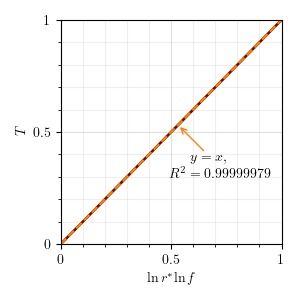

In [3]:
#| label: isocondffit

canvas = Canvas(size = (3, 3))
ax = canvas.make_ax()
allT, allr = [], []
for f, T in zip(condfs, condgeotherms):
    f = min(0.999, f)
    h = np.linspace(0, 1, len(T))
    rstar = r_star(h, f)
    ax.line(
        rchan := Channel(np.log(rstar) / np.log(f), lims = (0, 1), label = r'$\ln{r^{*}}{\ln{f}}$'),
        Channel(T, label = '$T$'),
        c = cmap(f, condfs, style = 'turbo'),
        )
    allT.extend(T)
    allr.extend(rchan.data)
linscore = r2_score(allT, allr)
ax.line(
    np.linspace(0, 1, 10),
    np.linspace(0, 1, 10),
    color = '#ff7f0e',
    linestyle = '--',
    )
trendlabel = f"${r'y=x, \\ R^2 =' + str(round(linscore, 8))}$"
ax.annotate(
    rchan.data[15],
    rchan.data[15],
    label = trendlabel,
    points = (30, -30),
    arrowprops = dict(arrowstyle = "->", color = '#ff7f0e'),
    )
canvas

```{figure} #isocondf
:name: isocondf_fig

Summary of the scaling behaviours of isoviscous conduction for varying curvature parameter $f$. We obtain a natural scaling for $f$ versus $T_{av}$ with an $R^2$ better than 99%.

```

```{figure} #isocondffit
:name: isocondffit_fig

The analytical scaling of conductive temperature with $\ln{r^{*}}/\ln{f}$ holds empirically with extreme precision.

```

It is a requirement of thermal equilibrium that the thermal flux must be the same through every layer. In the planar case this results in a linear geotherm which, in a model with fixed and unitless boundary temperatures, results in a simple function of $T = z$ where $z$ is dimensionless depth from the top of the model. The average temperature is then trivially $T_{av}=0.5$. (For any system in pure conduction the *Nusselt* number is by definition $1$.)

In a cylindrical domain, however, the length of each layer $s$ is a function of depth and curvature as we have shown; consequently, shallower layers are able to transmit the same flux with a smaller temperature drop:

$$
\phi_q \propto s \cdot \frac{dT}{dh}
$$

To define the flux, we need the geothermal gradient. The conductive geotherm can be elegantly stated in terms of ${r^*}$ {numref}`isocondf_fig` {numref}`isocondffit_fig`:

$$
T(h) = \frac{\ln{{r^*}}}{\ln{f}}
$$

And so the geothermal gradient:

$$
\frac{dT}{dh} = \frac{f-1}{{r^*}\ln{f}}
$$

And finally the flux itself can be written as:

$$ \begin{align*}
\phi_q &\propto \frac{{s^*}(f-1)}{{r^*}\ln{f}} \\
&= \frac{2(1-f)}{(f+1)\ln{f}}
\end{align*} $$

$$ \begin{align*}
&\to -1 &as \quad f \to 1 \\
&\to 0 &as \quad f \to 0
\end{align*} $$

Or very succinctly in terms of the 'true' radius of the mid-depth:

$$
\phi_q \propto \frac{1}{r_m \ln{f}}
$$

To facilitate comparison between systems of different curvature, we can then use the above to define a dimensionless planetary flux ${\phi_q}^{*}$ - which is really just another name for the *Nusselt* number $\mathrm{Nu}$:

$$ \begin{align*}
{\phi_q}^{*} &= \frac{ {\phi_q} }{ {\phi_q}_c } \\
&\equiv \mathrm{Nu}
\end{align*} $$

Where the subscript $c$, here and elsewhere, denotes a purely conductive endmember. Because $\mathrm{Nu}$ now inherits a dependency on $f$, it is no longer equivalent to the dimensionless surface temperature gradient, and so it is important always to present and discuss it in its proper terms as a ratio of fluxes.

Just as the flux now scales with $f$, so must the average mantle temperature. In the planar case, the average temperature of the system is always half the temperature drop. In the cylindrical case, however:

$$ \begin{align*}
T_{\mathrm{av}} &= \dfrac{1}{2} \large{\sqrt[e]{\text{f}}} \\
&\equiv T_{c}
\end{align*} $$

The relationship is apparent in the numerical results {numref}`isocondf_fig`.

### Instability and convection

An implication of $\mathrm{Nu}$'s dependency on curvature is that the upper and lower boundaries must no longer be symmetrical. This invalidates many of the assumptions that made the planar case amenable to analysis. The additional space at the top of the model now allows more room for downwellings relative to basal upwellings, tending to promote instability [@Jarvis1991-ir]; on the other hand, the curved geotherm and the increased surface for radiating heat would tend to permit a comparatively thicker upper boundary layer. The effect of these countervailing forcings on the fundamental scalings of $\mathrm{Nu}$, $\mathrm{Ra}$, $\mathrm{Ra}_{\mathrm{cr}}$, and the all-important relation $\mathrm{Nu} \propto R^{\beta}$ is not obvious.

To begin to unpack the complexities of convection in the annulus, we can start with the assumption that - as in the planar case - the convective steady state will eventually result in a broad intracellular region of uniform temperature $T_{\mathrm{cell}}$. Assuming a unit temperature drop $\Delta T = 1$, we can write:

$$ \begin{align*}
{\Delta T}_o &= T_{\mathrm{cell}} \\
{\Delta T}_i &= 1 - T_{\mathrm{cell}}
\end{align*} $$

Knowing that the inner and outer fluxes ${\phi_q}_i$ and ${\phi_q}_o$ must be equal at steady state, and that the outer boundary - due to its greater length - can sustain that flux with a gradient shallower by a factor of $f$, we can deduce a relation between the outer and inner thermal gradients, and thence between $T_{\mathrm{cell}}$ and the inner and outer boundary layer thicknesses ${\Delta r}_i$ and ${\Delta r}_o$:

$$ \begin{align*}
f \frac{{\Delta T}_i}{{\Delta r}_i} &= \frac{{\Delta T}_o}{{\Delta r}_o} \\
\frac{{\Delta r}_i}{{\Delta r}_o} &= f \frac{1 - T_{\mathrm{cell}}}{T_{\mathrm{cell}}}
\end{align*} $$

For each of the two layers, we can prescribe a layer-specific *Rayleigh* number accordingly:

$$ \begin{align*}
\mathrm{Ra}_o &\propto T_{\mathrm{cell}} {{\Delta r}_o}^3 \\
\mathrm{Ra}_i &\propto (1 - T_{\mathrm{cell}}) {{\Delta r}_i}^3
\end{align*} $$

Having maintained non-dimensionality throughout, it is simple relate these two boundary *Rayleigh* numbers to the bulk $Ra$ value:

$$
\mathrm{Ra}_{\mathrm{layer}} = \mathrm{Ra} \cdot {\Delta T}_{\mathrm{layer}} \cdot {{\Delta r}_{\mathrm{layer}}}^3
$$

At this point, however, we have exhausted the insight we can obtain without making further assumptions. If we provide that the inner and outer boundary thicknesses must be the same, as they are in the planar case, we can see that:

$$
T_{\mathrm{cell}} = \frac{f}{f + 1} \quad \leftarrow {\Delta r}_i = {\Delta r}_o
$$

This, however, would imply that the inner and outer *Rayleigh* numbers are divergent. If we instead choose to conserve $Ra$, then: [@`Jarvis1993-cb]

$$
T_{\mathrm{cell}} = \frac{1}{1 + f^{-3/4}} \quad \leftarrow \mathrm{Ra}_i = \mathrm{Ra}_o
$$

Both possibilities converge on $0.5$ when $f\to1$ and $0$ when $f\to0$, as we would expect.

However it is estimated, it is clear that, as $Ra$ increases and boundaries thin, more of the mantle will fall in the intracellular region and global temperatures as a whole will approach $T_{cell}$. Conversely, if $Ra$ slips below its critical value, the boundary layers will disapper and the entire domain will enter the conductive regime: $T^{av} = T_{c}$. These two temperatures therefore make up respectively the lower and upper endmembers of global temperature:

$$ \begin{align*}
T_{\mathrm{av}} &\approx T_{c}, \quad \mathrm{Ra} < \mathrm{Ra}_{\mathrm{cr}} \\
&\to T_{\mathrm{cell}}, \quad \mathrm{Ra} \to \infty
\end{align*} $$

It makes intuitive sense that the effect of increasing $\mathrm{Ra}$ should be to decrease global temperatures, since that is exactly why convection is preferred wherever possible - though this intuition may not hold for all rheologies.

Of course, what we desire most of all is a cylindrical scaling for the mantle convection power law $Nu \propto R^{\beta}$. Following [@Jarvis1993-cb] and mandating equality of inner and outer $\mathrm{Ra}_{\mathrm{layer}}$, it is possible to construct a 'geometric correction' $g(f)$ that functions as a coefficient of the *beta* scaling:

$$
g(f) = \frac{\mathrm{Nu}_{c}}{{T_{\mathrm{cell}}}^{4/3}} \quad \leftarrow \mathrm{Ra}_i = \mathrm{Ra}_o
$$

$$
\mathrm{Nu} = g(f) \cdot R^{\frac{1}{3}}
$$

Using this scaling, Jarvis was able to obtain a *beta* exponent of $0.321 \pm 0.001$ across four values of $f$ from $(1.0 - 0.1)$ [@Jarvis1993-cb].